In [1]:
!nvidia-smi

Thu Jan 29 07:24:28 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P0             44W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
HOME = os.getcwd()
print(HOME)

/content


In [4]:
%pip install --upgrade ultralytics supervision roboflow onnx onnx2tf
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Setup complete ✅ (12 CPUs, 83.5 GB RAM, 39.5/235.7 GB disk)


In [5]:
!yolo task=detect mode=predict model=yolo11n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

image 1/1 /content/dog.jpeg: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 108.5ms
Speed: 2.8ms preprocess, 108.5ms inference, 38.7ms postprocess per image at shape (1, 3, 640, 384)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


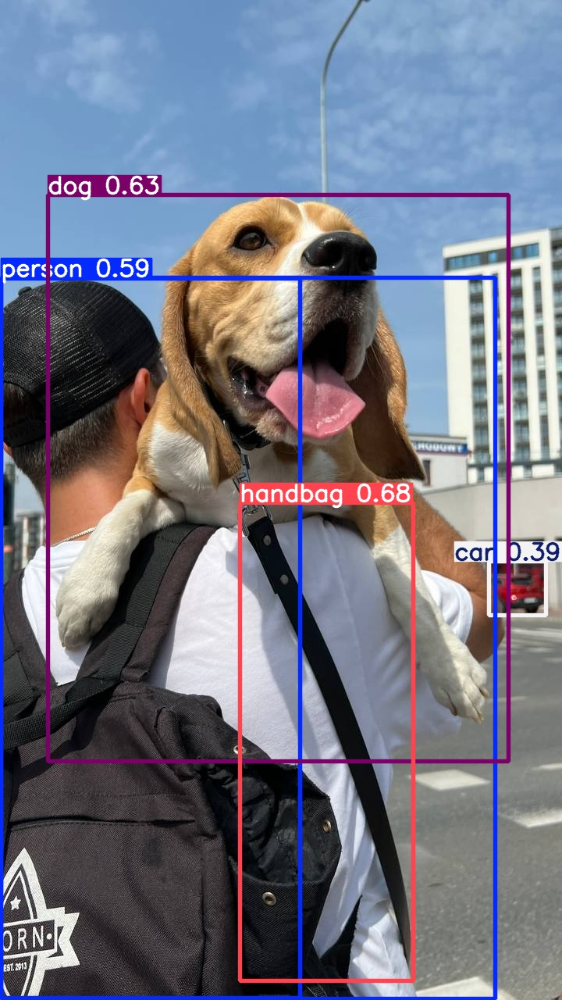

In [6]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/predict/dog.jpg', width=600)

In [7]:
from ultralytics import YOLO
from PIL import Image
import requests

model = YOLO('yolo11n.pt')
image = Image.open(requests.get('https://media.roboflow.com/notebooks/examples/dog.jpeg', stream=True).raw)
result = model.predict(image, conf=0.25)[0]


0: 640x384 2 persons, 1 car, 1 dog, 1 handbag, 90.0ms
Speed: 3.1ms preprocess, 90.0ms inference, 18.5ms postprocess per image at shape (1, 3, 640, 384)


In [8]:
result.boxes.xyxy

tensor([[3.0705e+02, 6.4340e+02, 5.2918e+02, 1.2559e+03],
        [6.1387e+01, 2.4994e+02, 6.5166e+02, 9.7414e+02],
        [1.7901e+00, 3.5551e+02, 6.3408e+02, 1.2788e+03],
        [1.1987e+00, 3.5620e+02, 3.8467e+02, 1.2776e+03],
        [6.2617e+02, 7.1818e+02, 6.9975e+02, 7.8754e+02]], device='cuda:0')

In [9]:
result.boxes.conf

tensor([0.6828, 0.6284, 0.5945, 0.3926, 0.3867], device='cuda:0')

In [10]:
result.boxes.cls

tensor([26., 16.,  0.,  0.,  2.], device='cuda:0')

In [11]:
import supervision as sv

detections = sv.Detections.from_ultralytics(result)

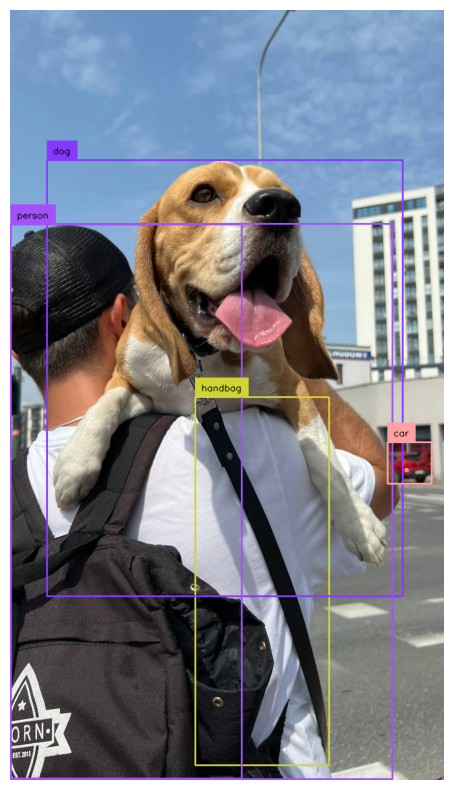

In [12]:
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator(text_color=sv.Color.BLACK)

annotated_image = image.copy()
annotated_image = box_annotator.annotate(annotated_image, detections=detections)
annotated_image = label_annotator.annotate(annotated_image, detections=detections)

sv.plot_image(annotated_image, size=(10, 10))

In [13]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(7) # version of dataset in roboflow
dataset = version.download("yolov11")

/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-7 in yolov11:: 100%|██████████| 56800/56800 [00:06<00:00, 8492.69it/s] 


In [14]:
%cd {HOME}

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=150 imgsz=768 plots=True # previous epoch: 10

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml \
# epochs=50 imgsz=640 batch=16 lr0=0.003 lrf=0.01 optimizer=AdamW \
# momentum=0.937 weight_decay=0.0005 warmup_epochs=5 \
# freeze=0 patience=30 cos_lr=True \
# box=7.5 cls=1.0 dfl=1.5 \
# hsv_h=0.015 hsv_s=0.7 hsv_v=0.4 mosaic=1.0 mixup=0.1 fliplr=0.5 \
# plots=True

# !yolo task=detect mode=train model=yolo11s.pt \
# data={dataset.location}/data.yaml \
# epochs=100 imgsz=768 batch=32 \
# lr0=0.002 lrf=0.01 optimizer=AdamW \
# momentum=0.937 weight_decay=0.0005 \
# warmup_epochs=3 \
# freeze=0 \
# patience=30 cos_lr=True \
# mosaic=0.5 mixup=0.02 fliplr=0.5 \
# hsv_h=0.015 hsv_s=0.4 hsv_v=0.4 \
# plots=True

# !yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml \
# epochs=150 imgsz=768 batch=120 lr0=0.0025 optimizer=SGD \
# freeze=2 patience=30 cos_lr=True \
# plots=True

!yolo task=detect mode=train model=yolo11s.pt \
data={dataset.location}/data.yaml \
epochs=150 imgsz=320 batch=64 \
optimizer=SGD \
warmup_epochs=3 \
patience=30 \
plots=True


/content
Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/datasets/erotica-detection-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overla

In [15]:
%load_ext tensorboard
%tensorboard --logdir /content/runs/detect

<IPython.core.display.Javascript object>

In [16]:
!ls {HOME}/runs/detect/train/

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg      val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg      val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch43680.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch43681.jpg  weights
labels.jpg			 train_batch43682.jpg


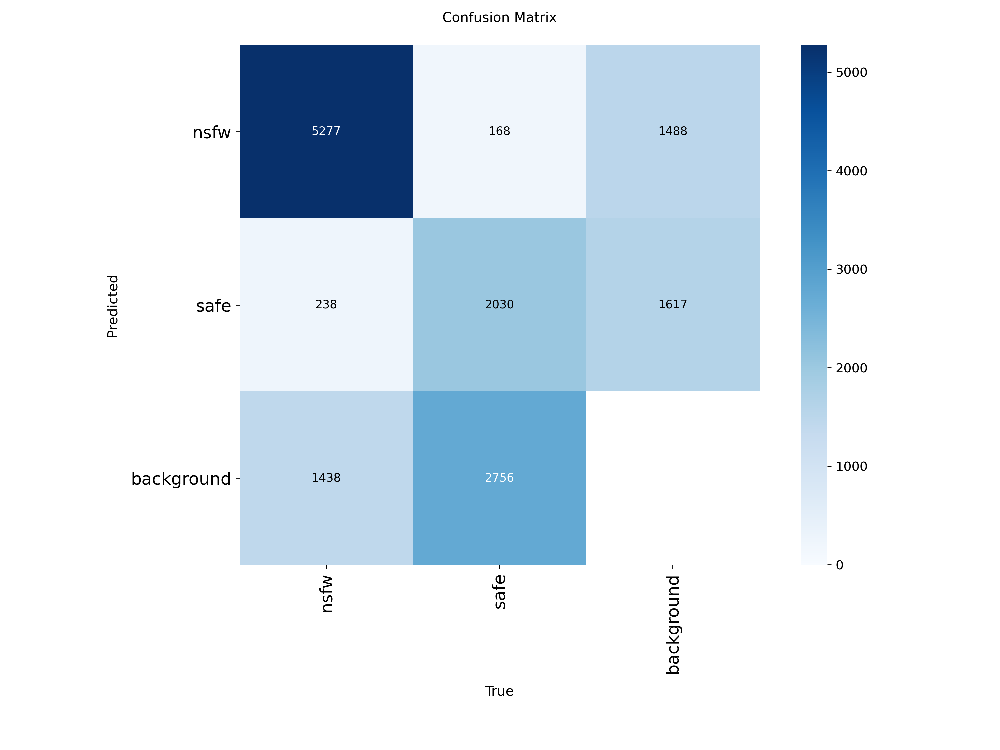

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

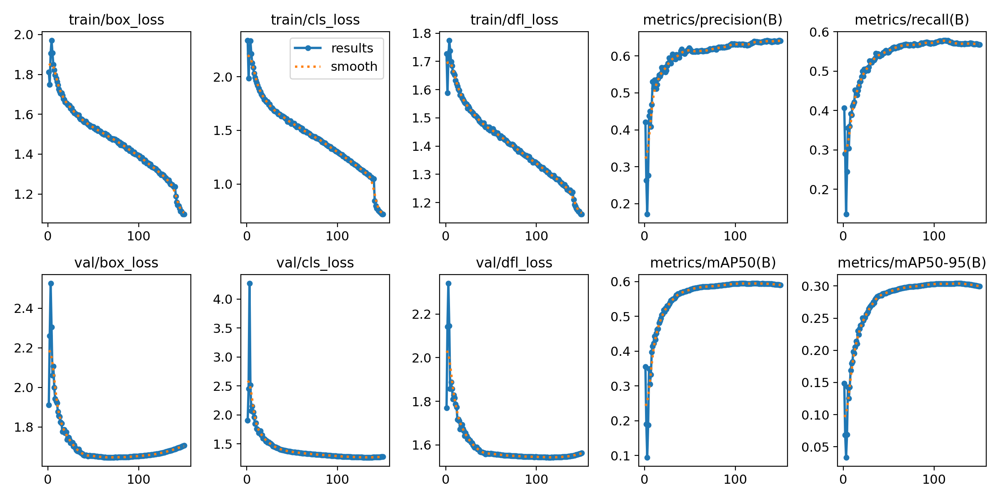

In [18]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

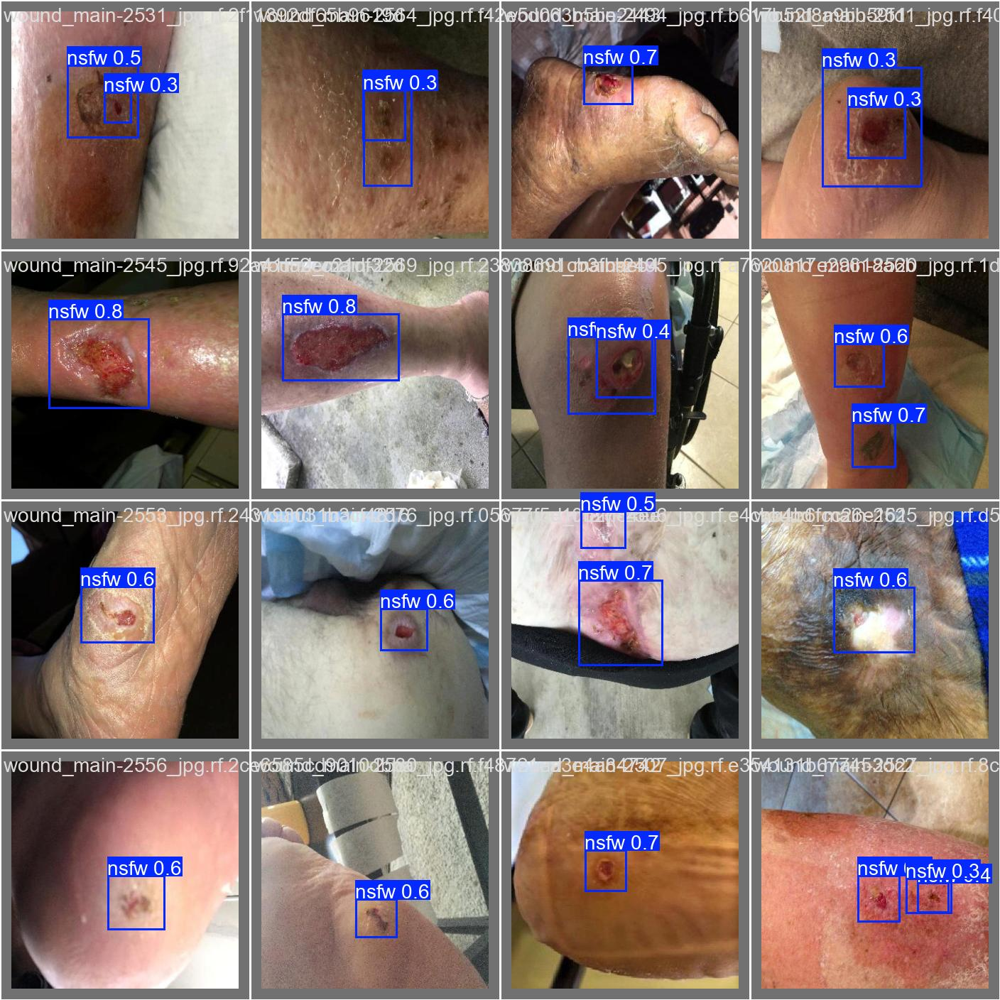

In [19]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

In [20]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1912.6±777.1 MB/s, size: 54.2 KB)
val: Scanning /content/datasets/erotica-detection-7/valid/labels.cache... 7130 images, 809 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 7130/7130 996.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 446/446 17.0it/s 26.3s
                   all       7130      11907       0.64       0.57      0.594      0.304
                  nsfw       4284       6953      0.759      0.745      0.787      0.429
                  safe       2266       4954      0.521      0.396      0.402      0.179
Speed: 0.2ms preprocess, 0.7ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


In [25]:
    !yolo task=detect mode=val \
        model= /content/runs/detect/train/weights/best.pt\
        data={dataset.location}/data.yaml \
        split=test \
        imgsz=320 \
        device=0 \
        batch=32

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1539.2±567.5 MB/s, size: 46.5 KB)
val: Scanning /content/datasets/erotica-detection-7/test/labels... 1333 images, 17 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1333/1333 1.5Kit/s 0.9s
val: New cache created: /content/datasets/erotica-detection-7/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 42/42 7.7it/s 5.5s
                   all       1333       2146      0.662      0.625      0.633      0.346
                  nsfw       1192       1927      0.808      0.793      0.841      0.478
                  safe        129        219      0.515      0.457      0.426      0.213
Speed: 0.2ms preprocess, 0.7ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/de

In [21]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/1333 /content/datasets/erotica-detection-7/test/images/03b88657f87cbb2c354ef68cc10ab04ea69b7ebfaae0732636cab1002433302a_jpg.rf.ecf1d5d435b547824a062b744d122ca0.jpg: 320x320 (no detections), 9.5ms
image 2/1333 /content/datasets/erotica-detection-7/test/images/04da2eabce826e56060ecb6c101c0034ffe62e90945bf972573890c5613ec18b_jpg.rf.1dfb3ec6db31a8b37e6157b6e2280dff.jpg: 320x320 (no detections), 9.0ms
image 3/1333 /content/datasets/erotica-detection-7/test/images/05101c6861a7fd415b497eb4245bc04d149aad7f637ac361e60c8860a1cad774_jpg.rf.496e2e08d188cbd9558189ab54f48c40.jpg: 320x320 5 safes, 9.0ms
image 4/1333 /content/datasets/erotica-detection-7/test/images/0527c86389462249_jpg.rf.7fe1faba250da9f4518e8119c18044f8.jpg: 320x320 1 safe, 9.4ms
image 5/1333 /content/datasets/erotica-detection-7/test/images/06d61dc

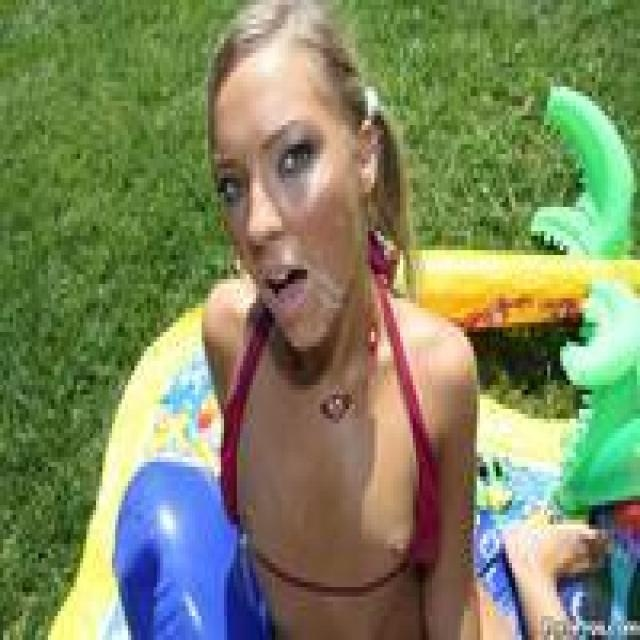

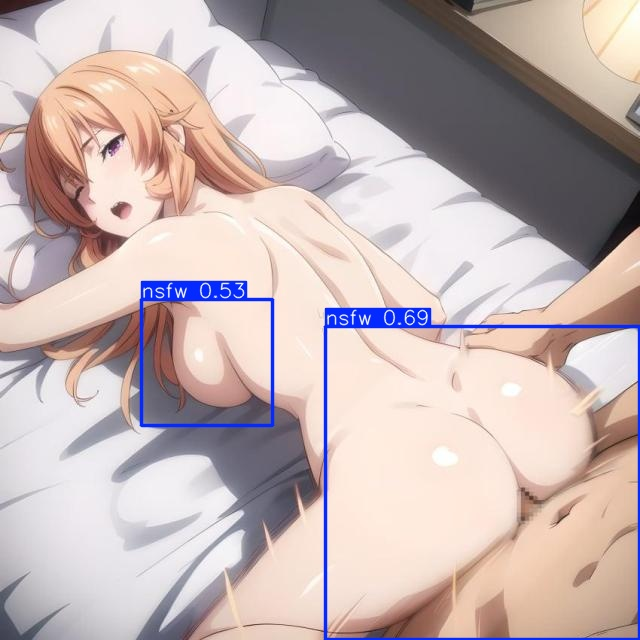

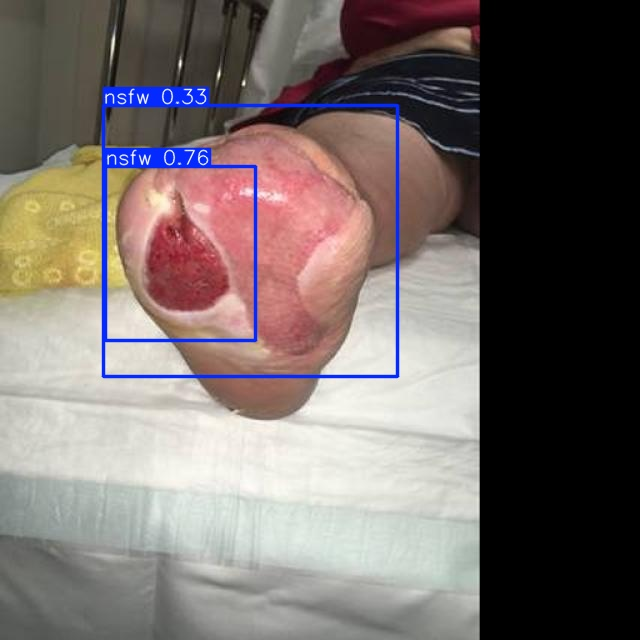

In [22]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

In [23]:
model.export(format="tflite",
             data="content/datasets/erotica-detection-7/data.yaml")

# Zip the results and weights folder
!zip -r yolov11n_results.zip /content/runs/detect/train/

# Zip the saved models folder
!zip -r yolov11n_saved_model.zip /content/yolo11n_saved_model

from google.colab import files

files.download('yolov11n_results.zip')
files.download('yolov11n_saved_model.zip')

Ultralytics 8.4.8 🚀 Python-3.12.12 torch-2.9.0+cu126 CPU (Intel Xeon CPU @ 2.20GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirements ['onnx2tf>=1.26.3,<1.29.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu', 'protobuf>=5'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 15 packages in 4.86s
Prepared 5 packages in 2.49s
Uninstalled 2 packages in 10ms
Installed 5 packages in 55ms
 + colorama==0.4.6
 - onnx2tf==1.29.16
 + onnx2tf==1.28.8
 + onnxruntime-gpu==1.23.2
 + onnxslim==0.1.82
 - protobuf==4.25.5
 + protobuf==6.33.4

requirements: AutoUpdate success ✅ 7.9s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorFlow SavedModel: starting export with tensorflow 2.19.0...

Exporting to ONNX opset version 22 is not supported. by 'torch.onnx.export()'. The highest opset version supported is 20. To use a newer opset version, consider 'torch.onnx.export(..., dynamo=True)'. 


ONNX: slimming with onnxslim 0.1.82...
ONNX: export success ✅ 1.8s, saved as 'yolo11n.onnx' (10.3 MB)
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to /content/calibration_image_sample_data_20x128x128x3_float32.npy...: 100% ━━━━━━━━━━━━ 1/1 49.6files/s 0.0s
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...
Saved artifact at 'yolo11n_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 640, 640, 3), dtype=tf.float32, name='images')
Output Type:
  TensorSpec(shape=(1, 84, 8400), dtype=tf.float32, name=None)
Captures:
  132729032462352: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  132729032460816: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  132729032461584: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  132729032465040: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  132729032465616: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.f

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>